# Earth Systems Playground — Wildfire Series
## Part 3: Scandinavia & the Baltic (Sweden, Finland, Norway, Estonia, Latvia, Lithuania)

**Series recap.** Part 1 (Eastern Mediterranean) found that country-level,
extreme-event framing beat pooled seasonal averages. Part 2 (Iberia) flipped
a hypothesis outright: the fuel-rich Atlantic northwest turned out to be
*more* climate-sensitive than the drier Mediterranean south, plausibly
because established fire-suppression infrastructure in the south absorbs
the climate signal before it becomes burned area. Part 2 also closed with an
open question: is "heat days / precipitation deficit" even the right lens
for a boreal, peat-adjacent fire regime, or does cumulative drying matter
more than any single hot day?

**What's different about this part, going in:**

1. **A genuinely different fuel and hydrology.** Boreal forest sits on
   organic, peat-rich soils that behave more like a drying sponge than
   Mediterranean maquis. The literature on boreal/peat fire behavior points
   to *cumulative* dryness — consecutive dry days, not isolated heat spikes
   — as the more physically relevant driver. So alongside the relative
   heat-day metric from Part 2 (kept for series comparability), this part
   adds a new one: **longest consecutive dry spell** per summer, per pixel.
2. **A sharper climate-change signal, per the literature**, which makes the
   trend section worth reading differently than Parts 1–2: less "did climate
   explain a given year" and more "is there a directional shift over 25
   years that the Mediterranean parts didn't show as clearly."
3. **Sub-region split**: Nordic boreal core (Sweden, Finland, Norway) vs.
   Baltic states (Estonia, Latvia, Lithuania) — different fire-management
   histories and slightly different climate-continentality gradients, worth
   testing separately rather than assuming "boreal" is one uniform regime,
   the same lesson Part 1 and Part 2 both taught the hard way.

**Data sources**: same core stack as Parts 1–2 — `MODIS/061/MOD14A1` /
`MYD14A1`, `NASA/LANCE/SNPP_VIIRS/C2` + `NOAA20_VIIRS/C2`,
`ECMWF/ERA5_LAND/DAILY_AGGR` / `MONTHLY_AGGR`, `FAO/GAUL/2015/level1`.


In [ ]:
!pip install pymannkendall

In [ ]:
# --- Imports ---
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import datetime

try:
    import pymannkendall as mk
    HAVE_MK = True
except ImportError:
    HAVE_MK = False
    print("pymannkendall not installed -- falling back to linear regression for trend.")


In [ ]:
# --- Earth Engine auth (same account as Parts 1-2) ---
try:
    ee.Initialize(project='composite-rune-448711-c0')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='composite-rune-448711-c0')


## 1. Area of interest

Sweden, Finland, Norway, Estonia, Latvia, Lithuania. Dissolved LSIB boundary for the full AOI, plus per-country geometries for the Nordic-vs-Baltic split in Section 4.

In [ ]:
countries = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
aoi_countries = ["Sweden", "Finland", "Norway", "Estonia", "Latvia", "Lithuania"]
aoi_fc = countries.filter(ee.Filter.inList("country_na", aoi_countries))
aoi = aoi_fc.geometry().dissolve()

country_geoms = {
    c: aoi_fc.filter(ee.Filter.eq("country_na", c)).geometry()
    for c in aoi_countries
}

nordic_names = ["Sweden", "Finland", "Norway"]
baltic_names = ["Estonia", "Latvia", "Lithuania"]

nordic_geom = aoi_fc.filter(ee.Filter.inList("country_na", nordic_names)).geometry().dissolve()
baltic_geom = aoi_fc.filter(ee.Filter.inList("country_na", baltic_names)).geometry().dissolve()

subregions = {
    "Nordic boreal core": nordic_geom,
    "Baltic states": baltic_geom,
}

Map = geemap.Map()
Map.centerObject(aoi, 4)
Map.addLayer(nordic_geom, {"color": "steelblue"}, "Nordic boreal core")
Map.addLayer(baltic_geom, {"color": "firebrick"}, "Baltic states")
Map


Map(center=[62.60647097515759, 19.16777514199033], controls=(WidgetControl(options=['position', 'transparent_b…

## 2. Long-record trend — Terra + Aqua cross-check

Same functions as Parts 1-2, unchanged -- they're region-agnostic. Watch for 2014 (Västmanland, Sweden's largest fire in modern history) and 2018 (a genuinely exceptional Scandinavian fire summer, ~25,000 individual fires reported across Sweden) as the sanity-check years for this part -- the equivalent of Part 1's 2021 and Part 2's 2017.

In [ ]:
def summer_fire_pixel_count(year, geom):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("MODIS/061/MOD14A1")
             .filterDate(start, end)
             .select("FireMask"))
    fire_any = col.map(lambda img: img.gte(7)).sum().gt(0)
    stats_ = fire_any.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=1000, maxPixels=1e10
    )
    return stats_.get("FireMask")

def summer_fire_pixel_count_myd(year, geom):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("MODIS/061/MYD14A1")
             .filterDate(start, end)
             .select("FireMask"))
    fire_any = col.map(lambda img: img.gte(7)).sum().gt(0)
    stats_ = fire_any.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=1000, maxPixels=1e10
    )
    return stats_.get("FireMask")

def region_area_km2(geom):
    return geom.area(maxError=1000).getInfo() / 1e6


Mann-Kendall trend: decreasing, p = 0.0109, Sen's slope = -14.06 km2/yr


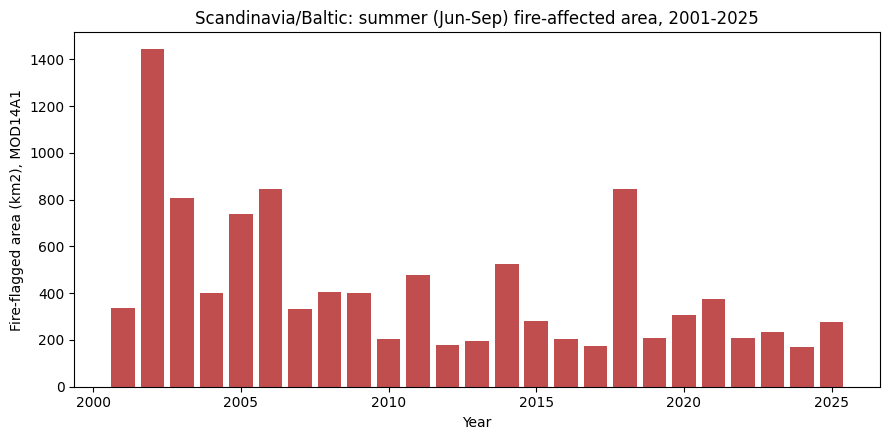

In [ ]:
years = list(range(2001, 2026))
records = []
for y in years:
    area_m2 = summer_fire_pixel_count(y, aoi).getInfo()
    records.append({"year": y, "burned_area_km2": (area_m2 or 0) / 1e6})

df_trend = pd.DataFrame(records)

x = df_trend["year"].values
yv = df_trend["burned_area_km2"].values
if HAVE_MK:
    result = mk.original_test(yv)
    print(f"Mann-Kendall trend: {result.trend}, p = {result.p:.4f}, Sen's slope = {result.slope:.2f} km2/yr")
else:
    slope, intercept, r, p, se = stats.linregress(x, yv)
    print(f"Linear trend: slope = {slope:.2f} km2/yr, R2 = {r**2:.3f}, p = {p:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(df_trend["year"], df_trend["burned_area_km2"], color="firebrick", alpha=0.8)
ax.set_title("Scandinavia/Baltic: summer (Jun-Sep) fire-affected area, 2001-2025")
ax.set_xlabel("Year"); ax.set_ylabel("Fire-flagged area (km2), MOD14A1")
plt.tight_layout()
plt.savefig("part3_trend_2001_2025.png", dpi=150)
plt.show()

# If 2014 and/or 2018 don't stand out clearly, don't assume the pipeline is
# wrong before checking two things first (in order): (1) Aqua cross-check,
# same as Parts 1-2; (2) whether MOD14A1's 1km resolution is simply too
# coarse to resolve the Vastmanland fire, which -- unlike the Iberian and
# Eastern Mediterranean events -- was a single, relatively contained ~140 km2
# burn scar rather than a diffuse multi-hundred-km2 regional event. A ~140
# km2 fire is a much smaller signal to detect at 1km pixel resolution than
# the regional fire seasons the earlier parts were tracking.


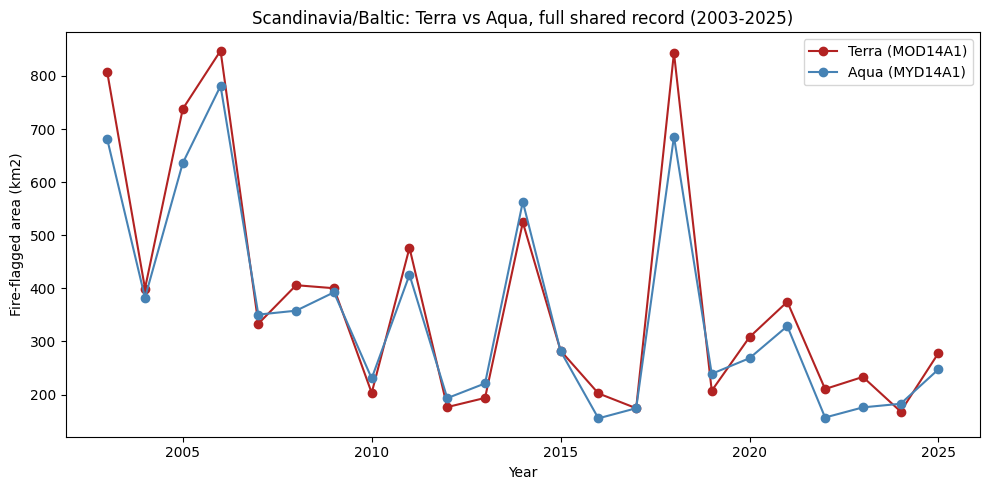

In [ ]:
aqua_years = list(range(2003, 2026))
aqua_records = []
for y in aqua_years:
    area_m2 = summer_fire_pixel_count_myd(y, aoi).getInfo()
    aqua_records.append({"year": y, "aqua_burned_area_km2": (area_m2 or 0) / 1e6})

df_trend_aqua = pd.DataFrame(aqua_records)

fig, ax = plt.subplots(figsize=(10, 5))
df_terra_shared = df_trend[df_trend["year"].isin(aqua_years)]
ax.plot(df_terra_shared["year"], df_terra_shared["burned_area_km2"], marker="o", color="firebrick", label="Terra (MOD14A1)")
ax.plot(df_trend_aqua["year"], df_trend_aqua["aqua_burned_area_km2"], marker="o", color="steelblue", label="Aqua (MYD14A1)")
ax.set_title("Scandinavia/Baltic: Terra vs Aqua, full shared record (2003-2025)")
ax.set_xlabel("Year"); ax.set_ylabel("Fire-flagged area (km2)")
ax.legend()
plt.tight_layout()
plt.savefig("part3_terra_vs_aqua_full_series.png", dpi=150)
plt.show()


## 3. Recent detail — VIIRS 375 m (2023-2026) and current-season snapshot

In [ ]:
def viirs_summer_hotspot_count(year, geom):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    snpp = ee.ImageCollection("NASA/LANCE/SNPP_VIIRS/C2").filterDate(start, end)
    noaa20 = ee.ImageCollection("NASA/LANCE/NOAA20_VIIRS/C2").filterDate(start, end)
    combined = snpp.merge(noaa20)
    detections = combined.select("Bright_ti4").map(lambda img: img.gt(0)).sum().gt(0)
    stats_ = detections.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=geom, scale=375, maxPixels=1e10
    )
    return stats_.get("Bright_ti4")

recent_years = [2024, 2025, 2026]
recent_records = []
for y in recent_years:
    area_m2 = viirs_summer_hotspot_count(y, aoi).getInfo()
    recent_records.append({"year": y, "hotspot_area_km2": (area_m2 or 0) / 1e6})

df_recent = pd.DataFrame(recent_records)
df_recent

# Same caveat as Parts 1-2: if running before Sep 30, 2026, prorate the 2026
# row by days elapsed before comparing to the complete 2024/2025 seasons.


,year,hotspot_area_km2
0,2024,614.180374
1,2025,638.991301
2,2026,284.429340


In [ ]:
today = datetime.datetime.utcnow().date()
window_start = (today - datetime.timedelta(days=30)).isoformat()
window_end = today.isoformat()

latest = ee.ImageCollection("NASA/LANCE/SNPP_VIIRS/C2") \
    .merge(ee.ImageCollection("NASA/LANCE/NOAA20_VIIRS/C2")) \
    .filterDate(window_start, window_end) \
    .select("Bright_ti4").max()

vis = {"min": 280, "max": 400, "palette": ["yellow", "orange", "red", "darkred"]}
Map2 = geemap.Map()
Map2.centerObject(aoi, 4)
Map2.addLayer(aoi, {"color": "gray"}, "AOI outline", opacity=0.3)
Map2.addLayer(latest.clip(aoi), vis, "VIIRS hotspots, last 30 days")
Map2


Map(center=[62.60647097515759, 19.16777514199033], controls=(WidgetControl(options=['position', 'transparent_b…

## 4. Climate drivers: relative heat-days (kept from Part 2) + longest dry spell (new)

Two metrics, run per sub-region:

- **Relative extreme-heat days** (region's own 90th-percentile summer daily-max temperature, 2001-2025 baseline) -- kept unchanged from Part 2 for cross-part comparability.
- **Longest consecutive dry spell** (max run of days with `total_precipitation_sum` below 1mm, Jun-Sep) -- new this part, meant to capture cumulative drying rather than isolated heat, which the boreal/peat literature suggests matters more here than it did in the Mediterranean parts.

⚠️ The dry-spell metric uses `ImageCollection.iterate()` to carry a running streak counter across each summer's ~122 daily images -- this is noticeably slower than the other metrics in this series. Expect it to take longer per region/year than anything in Parts 1-2.

In [ ]:
def build_heat_baseline(geom, start_year=2001, end_year=2025, percentile=90):
    baseline_col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
                     .filter(ee.Filter.calendarRange(6, 9, "month"))
                     .filter(ee.Filter.calendarRange(start_year, end_year, "year"))
                     .select("temperature_2m_max"))
    threshold_img = baseline_col.reduce(ee.Reducer.percentile([percentile])).rename("threshold")
    return threshold_img

def extreme_heat_days_relative(year, geom, threshold_img):
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("temperature_2m_max"))
    hot_day_count = col.map(lambda img: img.gt(threshold_img)).sum()
    val = hot_day_count.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9
    )
    return val.get("temperature_2m_max")

def longest_dry_spell(year, geom, precip_threshold_m=0.001):
    """Longest run of consecutive dry days (Jun-Sep) per pixel, area-averaged.
    Uses ImageCollection.iterate() to carry a running streak/max-streak pair
    of bands across the sorted daily sequence."""
    start = f"{year}-06-01"
    end = f"{year}-09-30"
    col = (ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
             .filterDate(start, end)
             .select("total_precipitation_sum")
             .sort("system:time_start"))
    img_list = col.toList(col.size())

    init = ee.Image(0).rename("streak").addBands(ee.Image(0).rename("maxstreak")).clip(geom)

    def accumulate(img, prev):
        img = ee.Image(img)
        prev = ee.Image(prev)
        streak = prev.select("streak")
        maxstreak = prev.select("maxstreak")
        is_dry = img.lt(precip_threshold_m)
        new_streak = streak.add(1).multiply(is_dry)
        new_max = maxstreak.max(new_streak)
        return new_streak.rename("streak").addBands(new_max.rename("maxstreak"))

    result = ee.Image(img_list.iterate(accumulate, init))
    max_streak_img = result.select("maxstreak")
    val = max_streak_img.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=geom, scale=10000, maxPixels=1e9
    )
    return val.get("maxstreak")


In [ ]:
# --- Build heat baselines once per sub-region (same pattern as Part 2) ---
heat_baselines = {label: build_heat_baseline(geom) for label, geom in subregions.items()}

subregion_records = []
for label, geom in subregions.items():
    area_km2 = region_area_km2(geom)
    threshold_img = heat_baselines[label]
    for y in years:
        fire_m2 = summer_fire_pixel_count(y, geom).getInfo()
        heat_days = extreme_heat_days_relative(y, geom, threshold_img).getInfo()
        dry_spell = longest_dry_spell(y, geom).getInfo()
        subregion_records.append({
            "region": label,
            "year": y,
            "fire_area_km2": (fire_m2 or 0) / 1e6,
            "region_area_km2": area_km2,
            "extreme_heat_days_p90": heat_days,
            "longest_dry_spell_days": dry_spell,
        })

df_boreal = pd.DataFrame(subregion_records)
df_boreal["fire_density_pct"] = df_boreal["fire_area_km2"] / df_boreal["region_area_km2"] * 100
df_boreal.head()


,region,year,fire_area_km2,region_area_km2,extreme_heat_days_p90,longest_dry_spell_days,fire_density_pct
0,Nordic boreal core,2001,156.451715,1.092050e+06,6.568449,10.788813,0.014326
1,Nordic boreal core,2002,535.148599,1.092050e+06,17.620380,12.321568,0.049004
2,Nordic boreal core,2003,662.459686,1.092050e+06,16.294471,11.626409,0.060662
3,Nordic boreal core,2004,315.361791,1.092050e+06,8.434753,8.211436,0.028878
4,Nordic boreal core,2005,524.939409,1.092050e+06,10.534223,10.201684,0.048069


Fire density vs relative (p90) extreme-heat days, by sub-region:
  Nordic boreal core: r = 0.59, p = 0.002, n = 25
  Baltic states: r = 0.21, p = 0.321, n = 25

Fire density vs longest dry spell, by sub-region:
  Nordic boreal core: r = 0.41, p = 0.041, n = 25
  Baltic states: r = 0.76, p = 0.000, n = 25


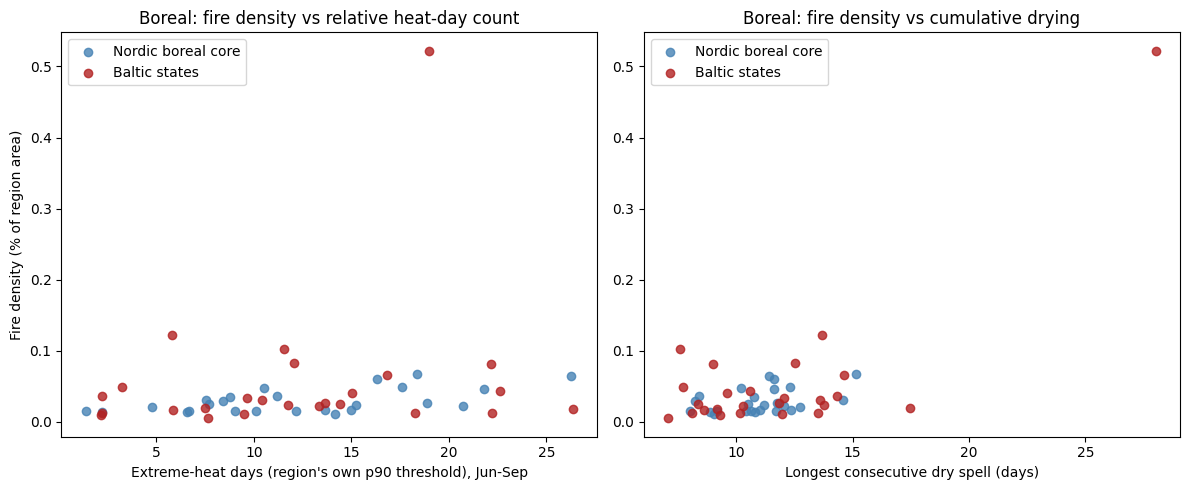

In [ ]:
print("Fire density vs relative (p90) extreme-heat days, by sub-region:")
for label in subregions:
    sub = df_boreal[df_boreal["region"] == label]
    r, p = stats.pearsonr(sub["extreme_heat_days_p90"], sub["fire_density_pct"])
    print(f"  {label}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

print("\nFire density vs longest dry spell, by sub-region:")
for label in subregions:
    sub = df_boreal[df_boreal["region"] == label]
    r, p = stats.pearsonr(sub["longest_dry_spell_days"], sub["fire_density_pct"])
    print(f"  {label}: r = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sub_colors = {"Nordic boreal core": "steelblue", "Baltic states": "firebrick"}
for label in subregions:
    sub = df_boreal[df_boreal["region"] == label]
    axes[0].scatter(sub["extreme_heat_days_p90"], sub["fire_density_pct"], label=label, color=sub_colors[label], alpha=0.8)
    axes[1].scatter(sub["longest_dry_spell_days"], sub["fire_density_pct"], label=label, color=sub_colors[label], alpha=0.8)

axes[0].set_xlabel("Extreme-heat days (region's own p90 threshold), Jun-Sep")
axes[0].set_ylabel("Fire density (% of region area)")
axes[0].set_title("Boreal: fire density vs relative heat-day count")
axes[0].legend()

axes[1].set_xlabel("Longest consecutive dry spell (days)")
axes[1].set_title("Boreal: fire density vs cumulative drying")
axes[1].legend()

plt.tight_layout()
plt.savefig("part3_heat_vs_dryspell_by_subregion.png", dpi=150)
plt.show()

# The comparison that matters most here: does longest_dry_spell outperform
# extreme_heat_days_p90 in this AOI, the way the boreal/peat literature would
# predict? If so, that's the headline methodological finding for this part --
# the "right" climate variable isn't universal, it's regime-dependent, and
# this series has now shown three different answers (heat, precip deficit,
# cumulative dryness) across three ecosystems.


In [ ]:
# --- Outlier check: Baltic dry-spell correlation with/without 2002 ---
baltic = df_boreal[df_boreal["region"] == "Baltic states"]
baltic_no2002 = baltic[baltic["year"] != 2002]

r_full, p_full = stats.pearsonr(baltic["longest_dry_spell_days"], baltic["fire_density_pct"])
r_excl, p_excl = stats.pearsonr(baltic_no2002["longest_dry_spell_days"], baltic_no2002["fire_density_pct"])

print(f"With 2002:    r = {r_full:.2f}, p = {p_full:.3f}")
print(f"Without 2002: r = {r_excl:.2f}, p = {p_excl:.3f}")

With 2002:    r = 0.76, p = 0.000
Without 2002: r = 0.08, p = 0.694


In [ ]:
# --- Outlier check: Nordic correlations, leave-one-out on the most extreme year ---
nordic = df_boreal[df_boreal["region"] == "Nordic boreal core"]

# Identify the year with the highest extreme-heat-day count (the ~26-day point)
extreme_year = nordic.loc[nordic["extreme_heat_days_p90"].idxmax(), "year"]
print(f"Highest heat-day year in Nordic core: {extreme_year}")

nordic_excl = nordic[nordic["year"] != extreme_year]

r_heat_full, p_heat_full = stats.pearsonr(nordic["extreme_heat_days_p90"], nordic["fire_density_pct"])
r_heat_excl, p_heat_excl = stats.pearsonr(nordic_excl["extreme_heat_days_p90"], nordic_excl["fire_density_pct"])
print(f"Heat-days  with {extreme_year}: r = {r_heat_full:.2f}, p = {p_heat_full:.3f}")
print(f"Heat-days  without {extreme_year}: r = {r_heat_excl:.2f}, p = {p_heat_excl:.3f}")

r_dry_full, p_dry_full = stats.pearsonr(nordic["longest_dry_spell_days"], nordic["fire_density_pct"])
r_dry_excl, p_dry_excl = stats.pearsonr(nordic_excl["longest_dry_spell_days"], nordic_excl["fire_density_pct"])
print(f"Dry-spell  with {extreme_year}: r = {r_dry_full:.2f}, p = {p_dry_full:.3f}")
print(f"Dry-spell  without {extreme_year}: r = {r_dry_excl:.2f}, p = {p_dry_excl:.3f}")

Highest heat-day year in Nordic core: 2018
Heat-days  with 2018: r = 0.59, p = 0.002
Heat-days  without 2018: r = 0.49, p = 0.015
Dry-spell  with 2018: r = 0.41, p = 0.041
Dry-spell  without 2018: r = 0.43, p = 0.035


## 5. Notes for the write-up (fill in after running)

- [ ] Trend headline + Terra/Aqua agreement. Does 2014 (Västmanland) show up
  at all, or is it below MOD14A1's effective detection floor at 1km? If
  invisible on Terra/Aqua, note this explicitly rather than treating it as a
  pipeline failure -- it may be a genuine resolution limitation worth a
  paragraph in itself, and worth a VIIRS-only spot-check for that single
  year/region even outside the 2023-2026 VIIRS window this notebook
  otherwise uses.
- [ ] Does 2018 stand out as expected (~25,000 fires reported across Sweden
  that summer)?
- [ ] Dry-spell vs heat-day comparison (Section 4) -- which metric wins,
  and does it differ between Nordic and Baltic sub-regions?
- [ ] Nordic vs Baltic: same climate variable, does it explain both
  sub-regions equally, or is there a fourth distinct pattern to add to the
  series (Greece: heat: Cyprus: precip; Atlantic Iberia: both; Med Iberia:
  neither)?
- [ ] Where 2026 stands, prorated by days elapsed -- same caveat as Parts 1-2.
- [ ] Revisit the "managed vs. less-managed" hypothesis from Part 2: Nordic
  countries have well-resourced fire services too, but very different
  population density and response-time geography (much larger, more remote
  forested area per capita) than southern Spain. If the suppression-capacity
  hypothesis is right, does it predict something different for a huge,
  sparsely-populated boreal forest than for a dense Mediterranean coastline?

## 6. Next in the series

**Part 4 — Synthesis.** All three parts' sub-region correlations side by
side: Greece (heat), Cyprus (precipitation), Türkiye's coast (neither),
Atlantic/Central-North Iberia (both), Mediterranean south Iberia (neither),
and whatever Nordic/Baltic add here. The organizing question going in:
does the "managed vs. less-managed" axis from Part 2 hold up as a general
explanation for *why* some regions show climate signal and others don't --
or does a three-ecosystem sample reveal it was coincidence, and the real
explanatory variable is still open.
